### Theory errors with SBI for LV2 

A short demo on accounting for theory errors with SBI for the LV2 Long Valley California Earthquake analysed in the paper. 

This is not a one-to-one reproduction of results since we tweak various knobs to make the demo run faster (fewer 1-D Earth model perturbations, fewer iterative least squares steps, fewer simulations).

In [ ]:
# first download the data by executing our custom download script. This will download the data to the `data/` folder.
!cd ../scripts; python custom_download.py --providers 'IRIS,NCEDC' --output_dir '../examples/data/LV2'

Quick and dirty look at the downloaded data

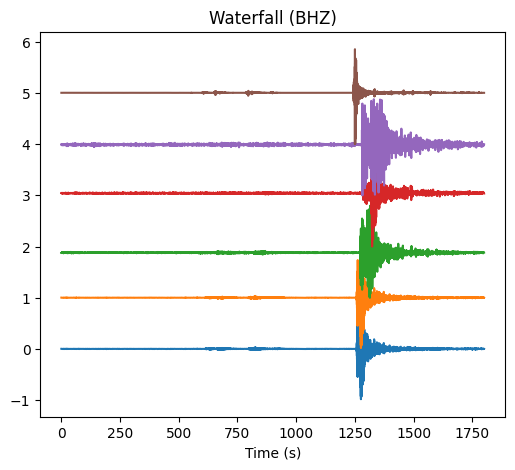

In [2]:

import glob
# recursively find .mseed files under the data folder
mseed_files = glob.glob('../examples/data/LV2/**/*BHZ*.mseed', recursive=True)
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

st = sum((read(f) for f in mseed_files), start=read(mseed_files[0]))
# st.filter("bandpass", freqmin=0.01, freqmax=0.05, corners=4, zerophase=True)

plt.figure(figsize=(6, 5))

for i, tr in enumerate(st):
    data = tr.data / np.max(np.abs(tr.data))
    t = np.arange(tr.stats.npts) / tr.stats.sampling_rate
    plt.plot(t, data + i)

plt.xlabel("Time (s)")
plt.title("Waterfall (BHZ)")
plt.show()

In [ ]:
# now preprocess the data using our custom preprocess script. This will save the preprocessed data to the `preprocessed/` folder.
!cd ../scripts; python custom_preprocess.py --data_dir '../examples/data/LV2' --output_dir '../examples/data/preprocessed/LV2'

### Theory errors through 1-D Earth model perturbations

We now build earth model perturbations on the SoCal 1-D model using CPS. We create 100 random perturbations of the 1-D model and compute the corresponding Green's functions with $\kappa=5\%$.

In [17]:
!cd ../scripts; python multi_CPS_perturbations.py --config '../examples/configs/model_perturbations.yaml' --output_dir '../examples/data/models/LV2_perturbations' --kappa_levels '5'

Parsing config file...
Successfully parsed config file.
At receiver init [0, 0, 0, 0, 0]
Running simulations: : 0it [00:00, ?it/s]
Running simulations: 100%|████████████████████| 100/100 [00:23<00:00,  4.20it/s]
Running simulations: : 0it [00:00, ?it/s]


In [8]:
import os
from seismo_sbi.sbi.configuration import SBI_Configuration
from seismo_sbi.sbi.pipeline import SingleEventPipeline
from seismo_sbi.sbi import utils as utils

config_path = "./configs/LV2.yaml"

print("Parsing config file...")
config = SBI_Configuration()
config.parse_config_file(config_path)
print("Successfully parsed config file.")

### Start SBI Pipeline

Pipeline = SingleEventPipeline 
sbi_pipeline = Pipeline(config.pipeline_parameters, config_path)
sbi_pipeline.compression_methods = config.compression_methods
sbi_pipeline.load_seismo_parameters(config.sim_parameters, config.model_parameters, config.dataset_parameters)

Parsing config file...
At receiver init [4, 1, 1, 2, 4]
Successfully parsed config file.


Let's plot receiver geometry alongside the 1-D Earth model perturbations for this setup. We also plot the Pham 2021 MT solution.,

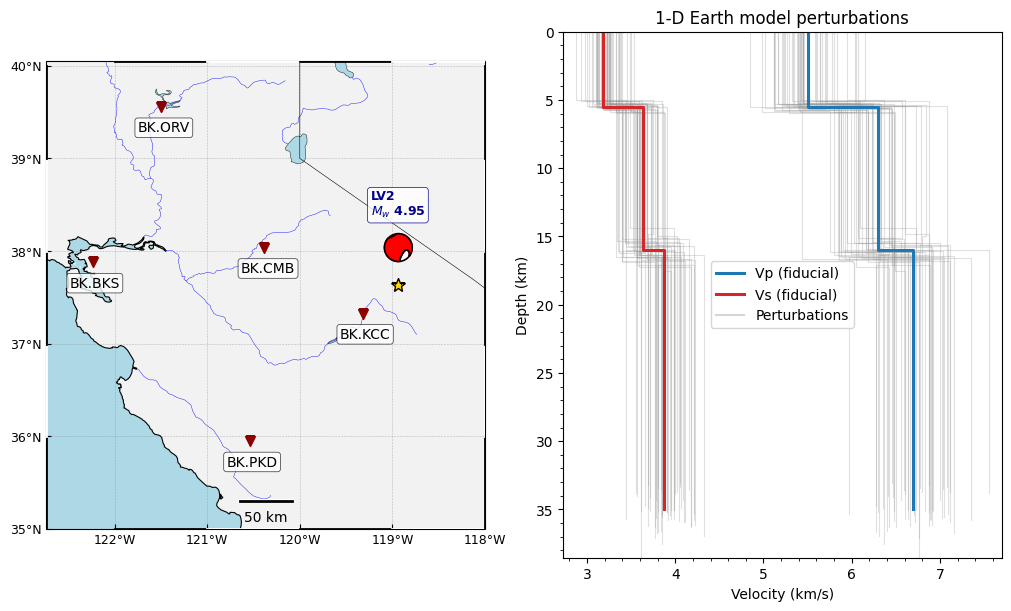

In [6]:
from seismo_sbi.plotting.velocity_models import plot_perturbations, add_event_to_map
from seismo_sbi.instaseis_simulator.receivers import Receivers

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

event = {"moment_tensor": [2.5679503714262864e+16, 4088315540457834.0, 2.143170060059789e+16, 1138279029296896.2, -1.8092427075991144e+16, 1.5021729089952764e+16],
    "source_location": [37.636, -118.936, 5, 0],
    "name": "LV2",
    "offsets":((0.0, 0.4), (-0.3, 0.3))}
bb, text = event["offsets"]

fig = plt.figure(figsize=(10, 6), layout="constrained")

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(1, 2, 2)

receivers = sbi_pipeline.simulator_wrapper.simulator.receivers
receivers.plot(ax=ax0)
add_event_to_map(ax0, event, bb_offset=bb, text_offset=text)

fiducial, perturbations = (
    sbi_pipeline.simulator_wrapper
    .simulator
    .get_all_models_array()
)

fiducial = fiducial[:-1]
perturbations = perturbations[:, :-1, :]

plot_perturbations(
    fiducial,
    perturbations,
    ax=ax1,
    title="1-D Earth model perturbations",
    add_legend=True
)

ax1.set_ylabel("Depth (km)")


plt.show()

Load in the event data and prepare gradients / test noises.

In [9]:
test_jobs_paths = sbi_pipeline.simulate_test_jobs(config.dataset_parameters, config.test_job_simulations)
sbi_pipeline.compute_data_vector_properties(test_jobs_paths, config.real_event_jobs)
score_compression_data, extra_gradients = sbi_pipeline.compute_required_compression_data(config.compression_methods,
                                                                        config.model_parameters,  
                                                                        rerun_if_stencil_exists = config.pipeline_parameters.generate_dataset)
sbi_pipeline.load_compressors(config.compression_methods, score_compression_data, extra_gradients=extra_gradients, freeze=True)

sbi_pipeline.load_test_noises(config.sbi_noise_model, config.test_noise_models)


Running simulations: : 0it [00:00, ?it/s]
Running simulations: : 0it [00:00, ?it/s]


### Setup the SBI pipeline for the given job

Setting e.g. the data covariance levels and samplers

In [10]:
# Preparations for performing sbi
from copy import deepcopy
from seismo_sbi.sbi.types.results import InversionResult, InversionData, JobResult, InversionConfig, JobData

compressor_name = "theory_optimal_score"
config.sbi_method, config.likelihood_config, 
dataset_details=config.dataset_parameters
param_names = sbi_pipeline.parameters.names
likelihood_config = config.likelihood_config


job_data = sbi_pipeline.create_job_data(test_jobs_paths, config.real_event_jobs)
single_job = job_data[0]
sim_name, test_noise, D, theta0_dict, covariance, priors = single_job
if covariance is not None:
    sbi_pipeline.training_noise_sampler.set_adaptive_covariance_with_misc_data(covariance)
theta0, dataset_details  = sbi_pipeline.compute_theta0_and_update_dataset(param_names, dataset_details, theta0_dict)

### Computation of maximum likelihood solution $\mathbf{m}_\textrm{MLE}$

Both the Gaussian likelihood approach and the score compression approach need a good solution for the best fitting moment tensor parameters, since the problem is non-linear. We find this by a combination of iterative least squares and an optional step of MCMC.

In [11]:
print("Starting on simulation:", sim_name, "with compressor:", compressor_name, flush=True)
inversion_config = InversionConfig("", test_noise, compressor_name)

# run iterative least squares, updating the local covariance Ct each step
compression_data = sbi_pipeline.find_mle_and_set_compressor(D, covariance, priors, dataset_details, compressor_name=compressor_name)

Starting on simulation: LV2 with compressor: theory_optimal_score
Starting MLE


Performing iterative least squares for MLE fiducial:   0%|          | 0/8 [00:00<?, ?it/s]

chi^2: 5.18965, damping lambda: 0.100
New MLE:
moment_tensor: [3.177e+16, 5.586e+15, 1.276e+16, -1.825e+15, -9.589e+15, 1.381e+16]


Performing iterative least squares for MLE fiducial:  12%|█▎        | 1/8 [00:18<02:12, 18.99s/it]

chi^2: 0.89582, damping lambda: 0.100
New MLE:
moment_tensor: [3.486e+16, 3.895e+15, 1.357e+16, -2.407e+12, -1.225e+16, 1.235e+16]


...

chi^2: 0.83180, damping lambda: 0.100
New MLE:
moment_tensor: [3.151e+16, 3.723e+15, 1.361e+16, -1.869e+14, -1.348e+16, 1.247e+16]


Performing iterative least squares for MLE fiducial:  88%|████████▊ | 7/8 [02:31<00:21, 21.46s/it]

chi^2: 0.72098, damping lambda: 0.100
New MLE:
moment_tensor: [3.193e+16, 3.462e+15, 1.340e+16, -6.486e+14, -1.346e+16, 1.238e+16]


Performing iterative least squares for MLE fiducial: 100%|██████████| 8/8 [02:54<00:00, 21.78s/it]

Using best chi^2 model from iteration 4: chi^2=0.68458


### Gaussian covariance $\mathbf{C}(\mathbf{m}_\textrm{MLE})$
Let's plot the resulting Gaussian covariance at the best fitting model parameters $\mathbf{m}_\textrm{MLE}$

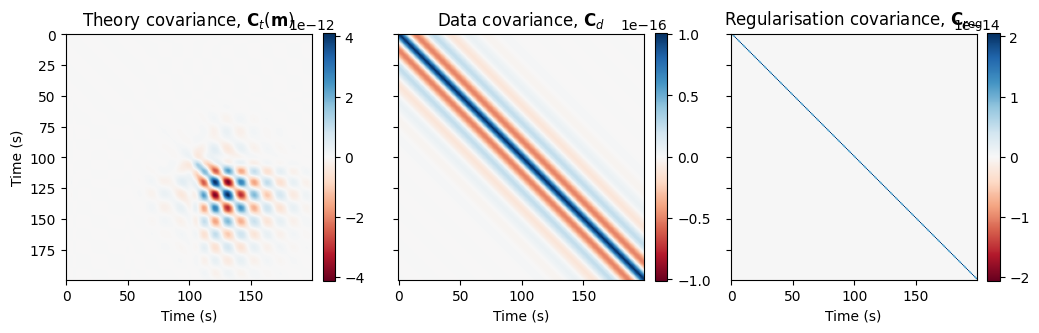

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
# --- Extract covariance matrices ---
theory_cov = sbi_pipeline.compressors['theory_optimal_score'].C.covariance_matrix_arrays[0]
data_cov = sbi_pipeline.data_cov_mat.covariance_matrix_arrays[0]

# --- Compute regularised (unmodelled) theory covariance ---
diag_regularisation_magnitude = config.compression_methods[0][1]["diag_regularisation_magnitude"]
data_vector_length = theory_cov.shape[0]
diag_reg_cov = np.eye(data_vector_length) * (np.max(np.diag(theory_cov)) * diag_regularisation_magnitude)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5))

im0 = axes[0].imshow(
    theory_cov, cmap='RdBu',
    vmin=-np.max(np.abs(theory_cov)), vmax=np.max(np.abs(theory_cov))
)
axes[0].set_title(r"Theory covariance, $\mathbf{C}_t(\mathbf{m})$")
axes[0].set_xlabel(f"Time (s)")
axes[0].set_ylabel(f"Time (s)")

# axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    data_cov, cmap='RdBu',
    vmin=-np.max(np.abs(data_cov)), vmax=np.max(np.abs(data_cov))
)
axes[1].set_title(r"Data covariance, $\mathbf{C}_d$")
axes[1].set_xlabel(f"Time (s)")
axes[1].set_yticklabels([])

# axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(
    diag_reg_cov, cmap='RdBu', 
    vmin=-np.max(np.abs(diag_reg_cov)), vmax=np.max(np.abs(diag_reg_cov))
)
axes[2].set_title(r"Regularisation covariance, $\mathbf{C}_\mathrm{reg}$")
axes[2].set_xlabel(f"Time (s)")
axes[2].set_yticklabels([])
# axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### SBI training

Build a dataset from the prior predictive model, compress the simulated observations (using randomly selected 1-D Earth models) with score compression, then train a neural network to model the theory errors.

In [13]:
sbi_inversion_data, sbi_job_result, sbi_model = sbi_pipeline.run_single_sbi_inversion(config.sbi_method, dataset_details, theta0, compression_data, priors, compressor_name=compressor_name)
sbi_inversion_result = InversionResult(sim_name, sbi_inversion_data, inversion_config)

MLE [ 3.35915677e+16  2.89893833e+15  1.33145819e+16 -7.45392136e+14
 -1.37298415e+16  1.22303312e+16]
theta0 None
bounds {'moment_tensor': array([[ 1.54200640e+16, -7.06936358e+15,  3.50277142e+15,
        -1.10232881e+16, -2.25414817e+16,  9.26999886e+15],
       [ 4.00000000e+16,  1.28672402e+16,  2.31263923e+16,
         9.53250382e+15, -4.91820128e+15,  1.51906636e+16]]), 'source_location': [37.636, -118.936, 5, 0], 'velocity_model': ['/home/alex/work/seismo-sbi/scripts/data/SoCal.plain.txt', 5]}


Running simulations:  13%|█▎        | 264/2000 [00:04<00:21, 80.38it/s]/home/alex/.local/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Compressing dataset: 100%|██████████| 2000/2000 [02:14<00:00, 14.85it/s]


Removed 5 rows due to high relative compression error.
 Neural network successfully converged after 130 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

### Gaussian likelihood MCMC

Now use the standard Gaussian likelihood approach to estimate the posterior using MCMC.

In [ ]:
print('Starting likelihood inversions.')
for result in sbi_pipeline.run_single_gaussian_likelihood_inversion(
    single_job, likelihood_config, compressor_name,
    deepcopy(sbi_pipeline.parameters), priors
):
    gl_inversion_result = result[1]

In [15]:
samples_theta0_dict = {'Optimal score compression': sbi_inversion_result.inversion_data,
                        'Gaussian Likelihood': gl_inversion_result.inversion_data}

### Posterior inference results

And now plot the resulting LV2 earthquake full moment tensor solutions for the two approaches.

Score compression SBI in blue, Gaussian likelihood based MCMC in red. We find much lower uncertainties with the Gaussian likelihood approach, which we interpret as significant overconfidence.

Added lune kwargs


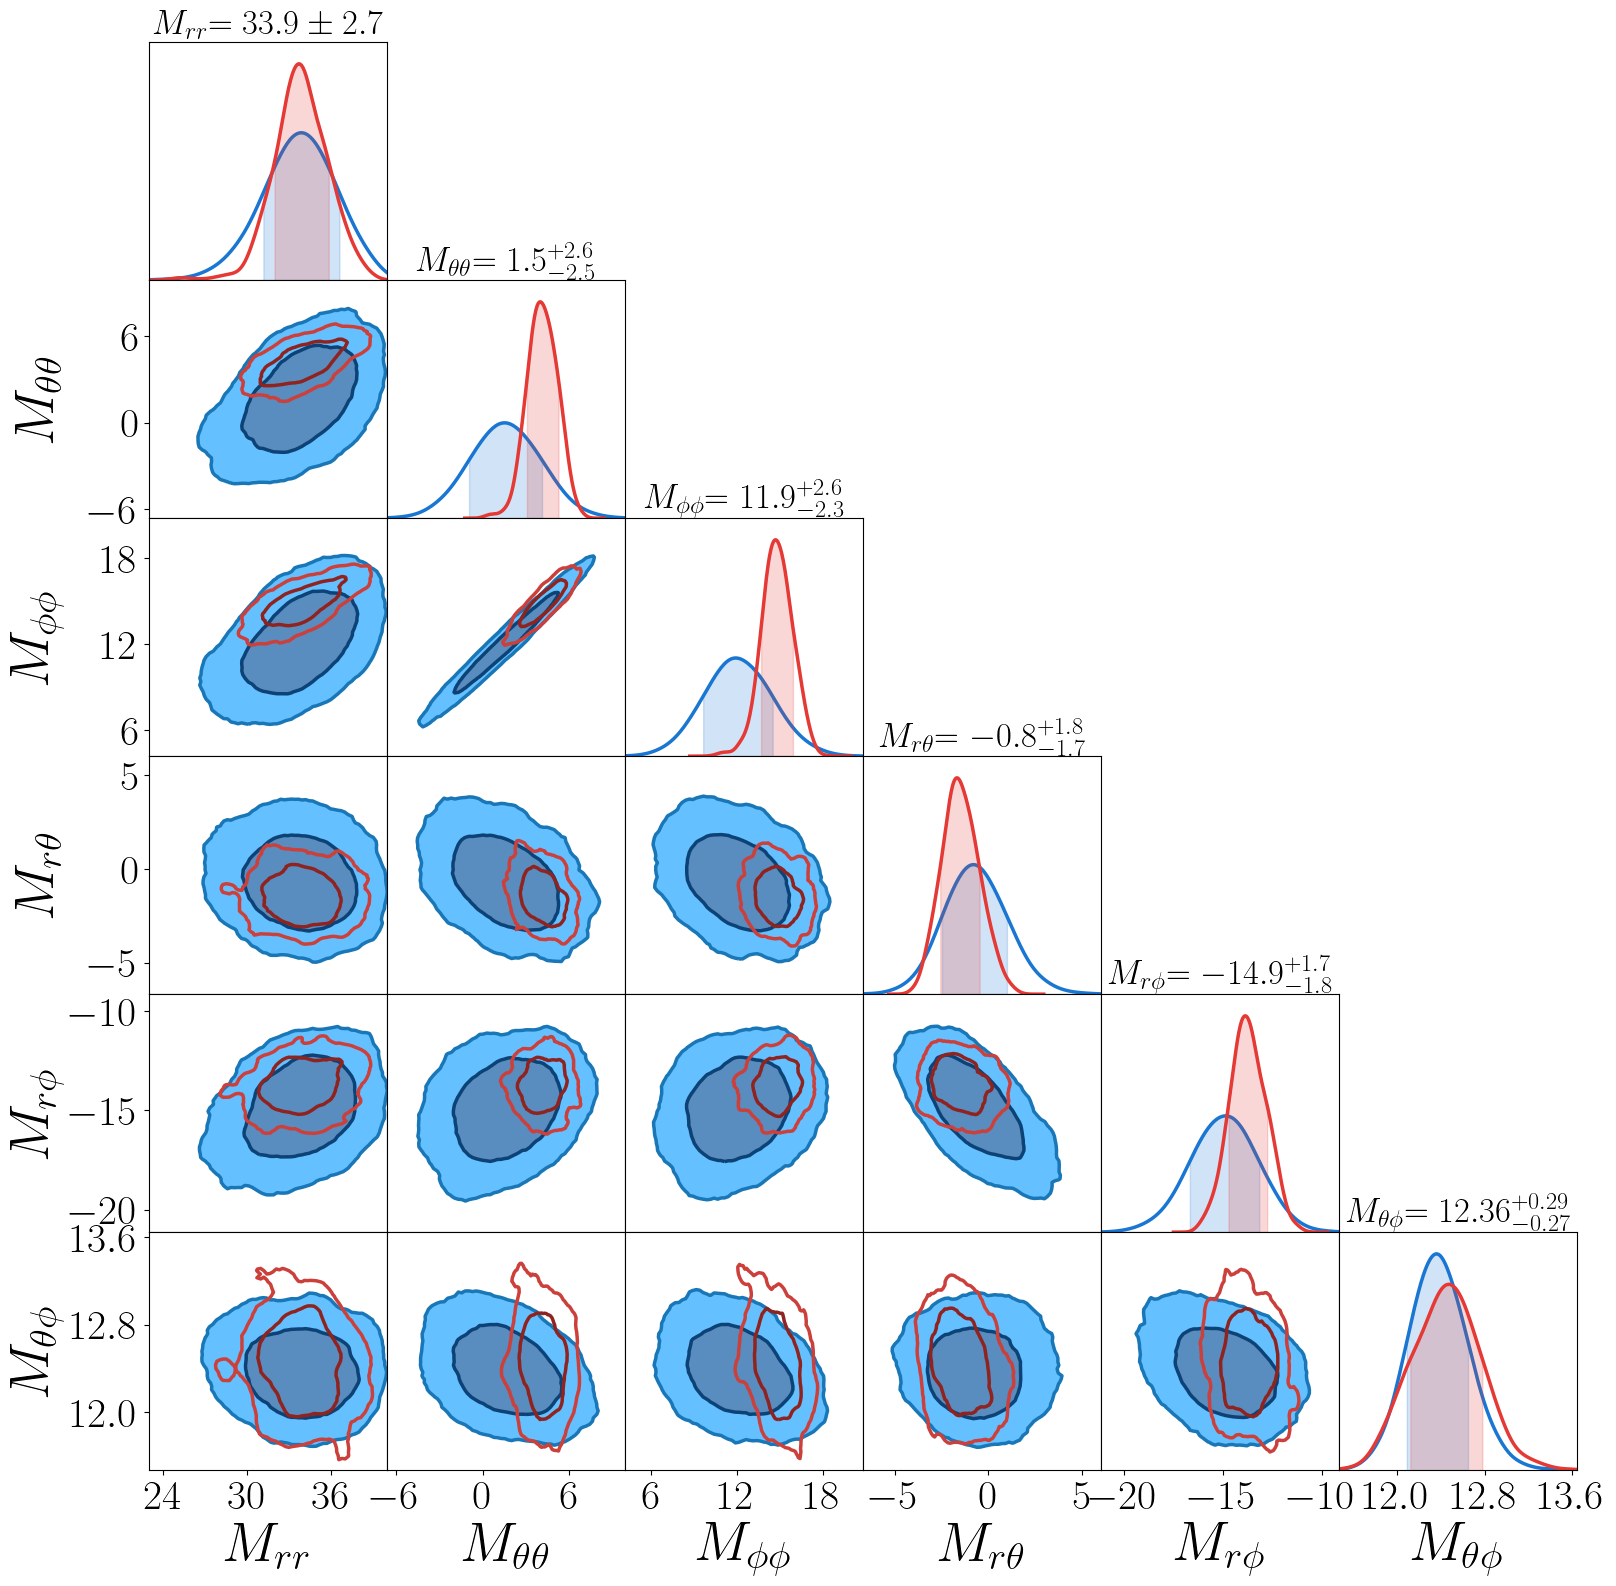

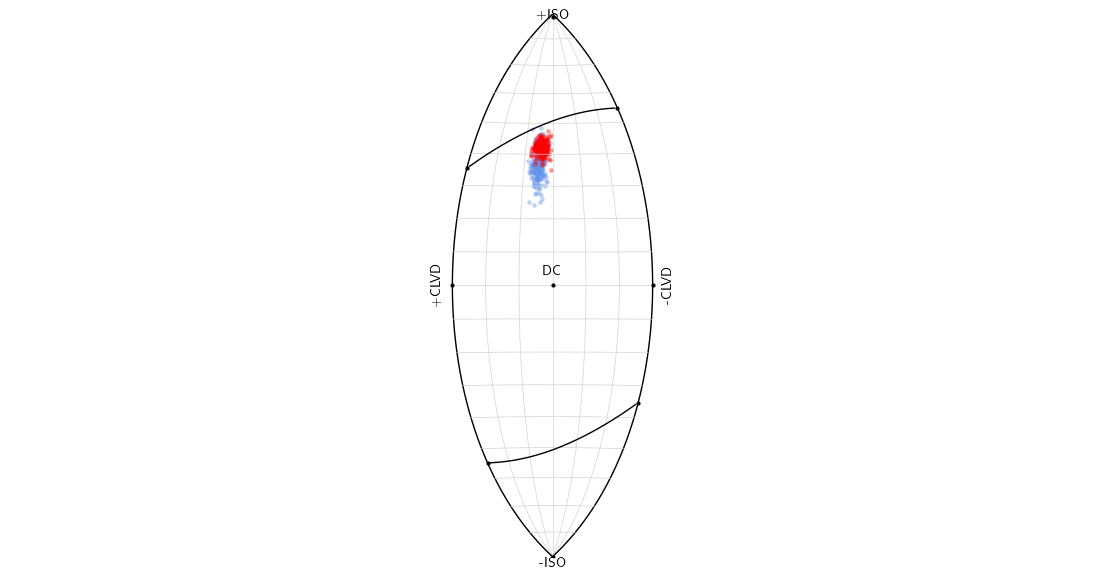

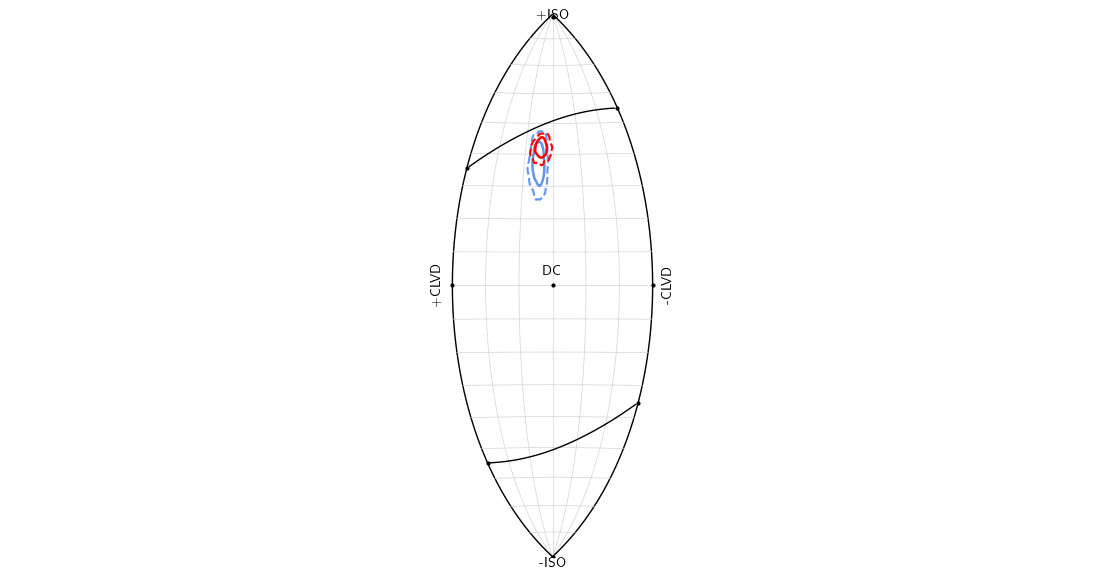

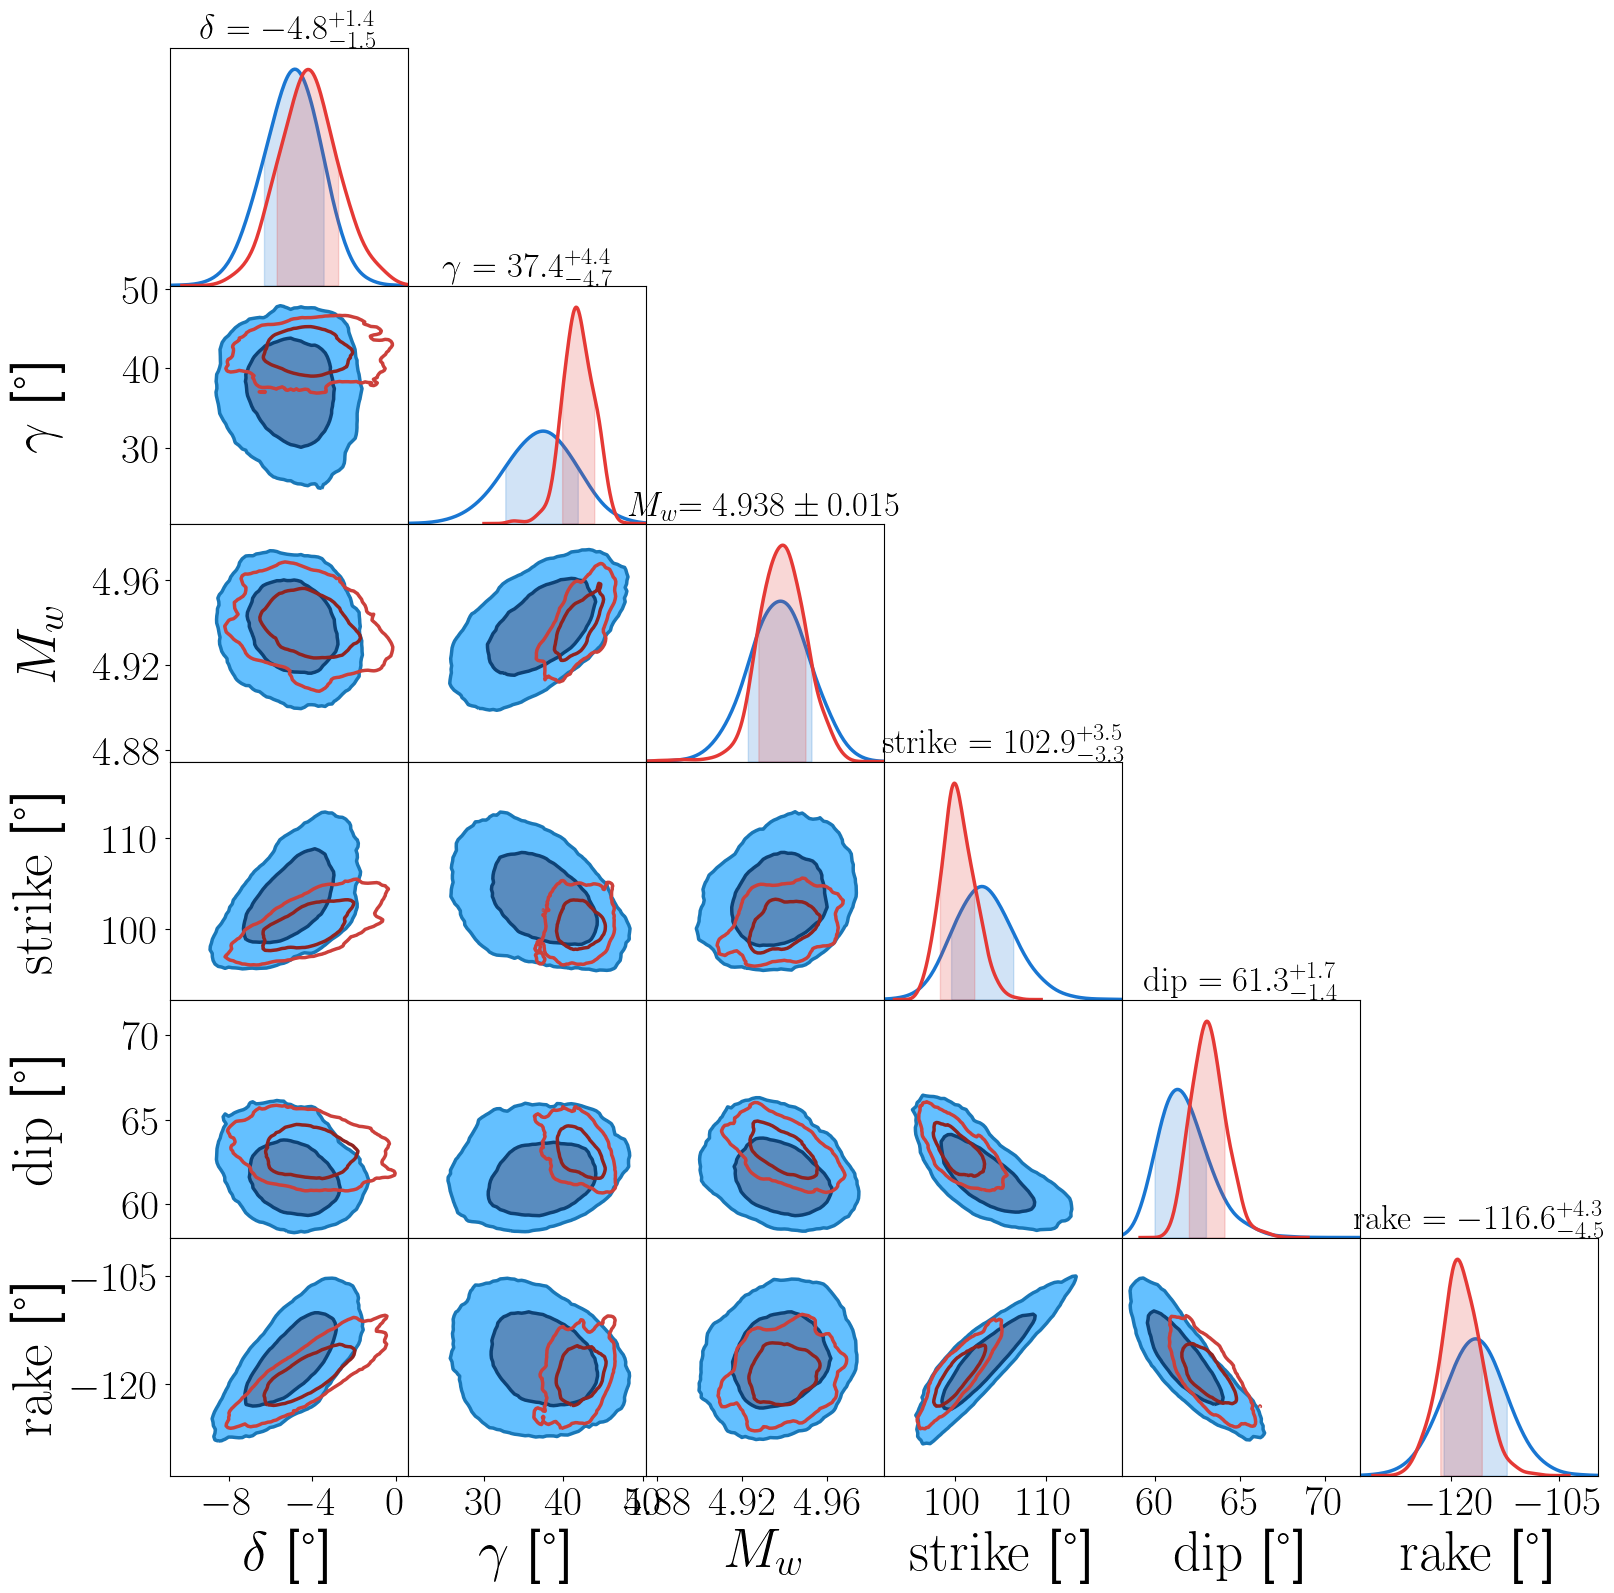

In [16]:
from seismo_sbi.sbi.pipeline import SBIPipelinePlotter
plotter = SBIPipelinePlotter('', sbi_pipeline.parameters)
plotter.initialise_posterior_plotter(None, sbi_pipeline.parameters.parameter_to_vector('information')[:6])
lune_kwargs = {'plot_beachballs': False}
kwargs = {'lune_kwargs': lune_kwargs}

samples_theta0_dict = {'Optimal score compression': sbi_inversion_result.inversion_data,
                        'Gaussian Likelihood': gl_inversion_result.inversion_data}
plotter.plot_chain_consumer('.',f'100k_all_inversions_{i}',samples_theta0_dict, savefig=False, **kwargs)